# EDA — GastroCorp NER 2026
Análisis exploratorio completo de los 4 datasets: `menu_train`, `menu_dev`, `recipe_train`, `recipe_dev`.

**Objetivo:** entender la distribución de datos, identificar las causas del F1=0.74 y diagnosticar riesgo de overfitting en el CRF.

## 0. Setup

In [ ]:
import json
import statistics
from collections import Counter, defaultdict
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F8F8',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

BASE = Path().resolve().parent   # sube de baselines/ → raíz
DATA = BASE

def load_jsonl(path):
    with open(path, encoding='utf-8') as f:
        return [json.loads(l) for l in f if l.strip()]

def safe_str(v):
    return '+'.join(sorted(str(x) for x in v)) if isinstance(v, list) else str(v)

mt = load_jsonl(DATA / 'menu_train.jsonl')
md = load_jsonl(DATA / 'menu_dev.jsonl')
rt = load_jsonl(DATA / 'recipe_train.jsonl')
rd = load_jsonl(DATA / 'recipe_dev.jsonl')

print(f'menu_train : {len(mt):,} seqs')
print(f'menu_dev   : {len(md):,} seqs')
print(f'recipe_train: {len(rt):,} seqs')
print(f'recipe_dev  : {len(rd):,} seqs')

menu_train : 11,070 seqs
menu_dev   : 2,366 seqs
recipe_train: 3,358 seqs
recipe_dev  : 719 seqs


## 1. Resumen general de datasets

In [2]:
def dataset_summary(name, records):
    lens = [len(r['tokens']) for r in records]
    tags = Counter(tag for r in records for tag in r.get('ner_tags', []))
    sl = sorted(lens)
    n = len(sl)
    print(f"\n{'=' * 55}")
    print(f'  {name}')
    print('\n' + '=' * 55)
    print(f'  Secuencias   : {len(records):,}')
    print(f'  Tokens total : {sum(lens):,}')
    print(f'  Seq len      : min={min(lens)}, p25={sl[n//4]}, median={int(statistics.median(lens))}, p75={sl[3*n//4]}, p95={sl[int(0.95*n)]}, max={max(lens)}')
    print(f'  Singles (1 token): {sum(1 for l in lens if l==1)}')
    if tags:
        total = sum(tags.values())
        print(f'  Etiquetas:')
        for tag, cnt in tags.most_common():
            print(f'    {tag:<25} {cnt:>6,}  ({cnt/total*100:.1f}%)')
    else:
        print('  (sin ner_tags)')

for name, ds in [('menu_train', mt), ('menu_dev', md), ('recipe_train', rt), ('recipe_dev', rd)]:
    dataset_summary(name, ds)


  menu_train

  Secuencias   : 11,070
  Tokens total : 72,579
  Seq len      : min=1, p25=3, median=5, p75=9, p95=17, max=57
  Singles (1 token): 973
  Etiquetas:
    B-INGREDIENT              19,246  (26.5%)
    I-INGREDIENT              17,092  (23.5%)
    I-DISH                     9,876  (13.6%)
    I-BEVERAGE                 9,829  (13.5%)
    B-BEVERAGE                 6,664  (9.2%)
    B-DISH                     5,430  (7.5%)
    B-BRAND                    2,531  (3.5%)
    I-BRAND                    1,911  (2.6%)

  menu_dev

  Secuencias   : 2,366
  Tokens total : 15,785
  Seq len      : min=1, p25=3, median=5, p75=9, p95=18, max=66
  Singles (1 token): 221
  (sin ner_tags)

  recipe_train

  Secuencias   : 3,358
  Tokens total : 41,702
  Seq len      : min=1, p25=7, median=11, p75=16, p95=27, max=111
  Singles (1 token): 67
  Etiquetas:
    B-INGREDIENT              25,894  (62.1%)
    I-INGREDIENT              15,189  (36.4%)
    B-BRAND                      335  (0.8%)
   

## 2. Distribución de etiquetas

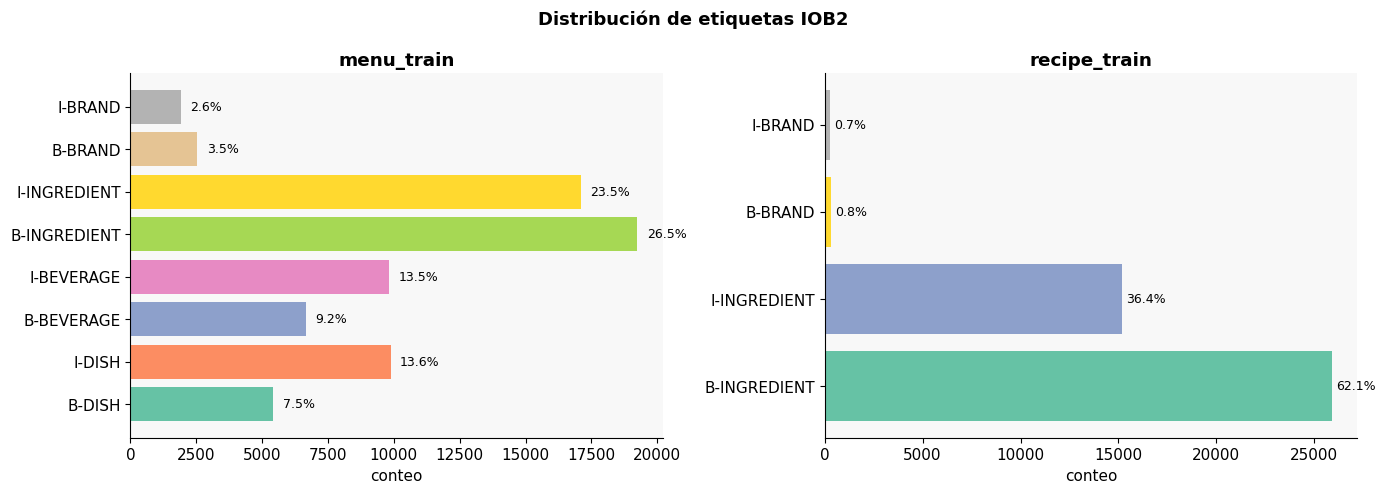

⚠️  recipe_train: secuencias con tag O = 0
⚠️  recipe_train: secuencias donde TODOS son entidades = 3358/3358 (100.0%)
    → El CRF nunca aprende a predecir "O" desde recipe_train


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, ds) in zip(axes, [('menu_train', mt), ('recipe_train', rt)]):
    tags = Counter(tag for r in ds for tag in r.get('ner_tags', []))
    total = sum(tags.values())
    labels = list(tags.keys())
    values = [tags[l] for l in labels]
    colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))
    bars = ax.barh(labels, values, color=colors)
    for bar, val in zip(bars, values):
        ax.text(bar.get_width() + total*0.005, bar.get_y() + bar.get_height()/2,
                f'{val/total*100:.1f}%', va='center', fontsize=9)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('conteo')

plt.suptitle('Distribución de etiquetas IOB2', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Alertas
rt_tags = Counter(tag for r in rt for tag in r.get('ner_tags', []))
has_O = sum(1 for r in rt if 'O' in r.get('ner_tags', []))
all_entity = sum(1 for r in rt if all(t != 'O' for t in r.get('ner_tags', ['O'])))
print(f'recipe_train: secuencias con tag O = {has_O}')
print(f'recipe_train: secuencias donde TODOS son entidades = {all_entity}/{len(rt)} ({all_entity/len(rt)*100:.1f}%)')
print(f'    → El CRF nunca aprende a predecir "O" desde recipe_train')

## 3. Distribución de longitud de secuencias

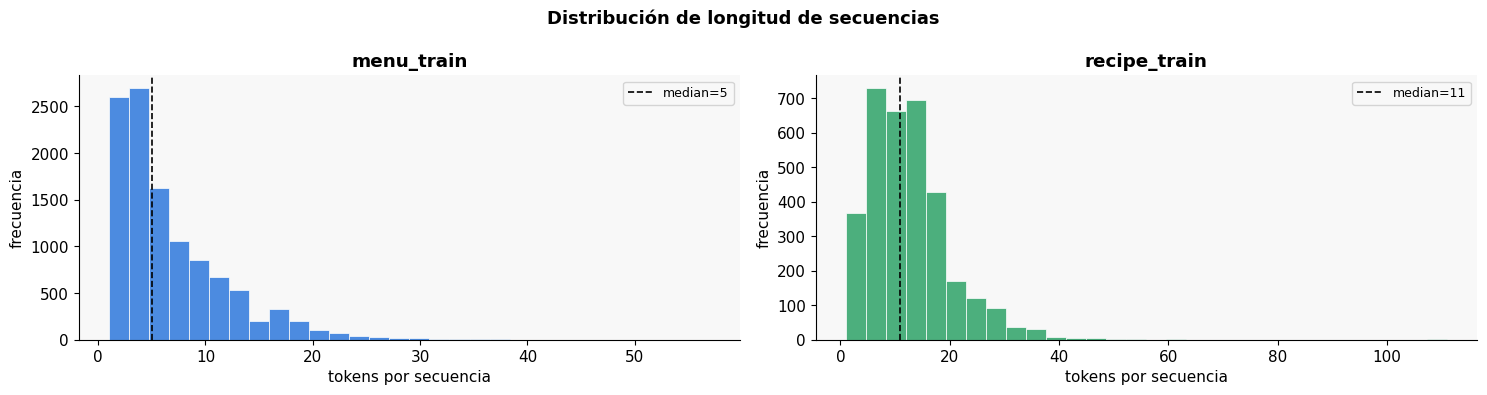

Observación: menu_train/dev tienen secuencias cortas (mediana ~5 tokens),
mientras recipe_train tiene secuencias más largas (mediana ~11 tokens).
Esto introduce un mismatch estructural entre dominios.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

datasets = [('menu_train', mt, '#4C8BE0'), ('recipe_train', rt, '#4CAF7D')]

for ax, (name, ds, color) in zip(axes, datasets):
    lens = [len(r['tokens']) for r in ds]
    ax.hist(lens, bins=30, color=color, edgecolor='white', linewidth=0.5)
    ax.axvline(statistics.median(lens), color='black', linestyle='--', linewidth=1.2, label=f'median={int(statistics.median(lens))}')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('tokens por secuencia')
    ax.set_ylabel('frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de longitud de secuencias', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observación: menu_train/dev tienen secuencias cortas (mediana ~5 tokens),')
print('mientras recipe_train tiene secuencias más largas (mediana ~11 tokens).')
print('Esto introduce un mismatch estructural entre dominios.')

## 4. Vocabulario y OOV

=== OOV Analysis ===
  menu_train vocab   : 8,432
  recipe_train vocab : 2,424
  All train vocab    : 9,867
  menu_dev vocab     : 3,585
  OOV types          : 966  (26.9% del vocab de dev)
  OOV token instances: 1,115 / 15,785  (7.1% de los tokens de dev)


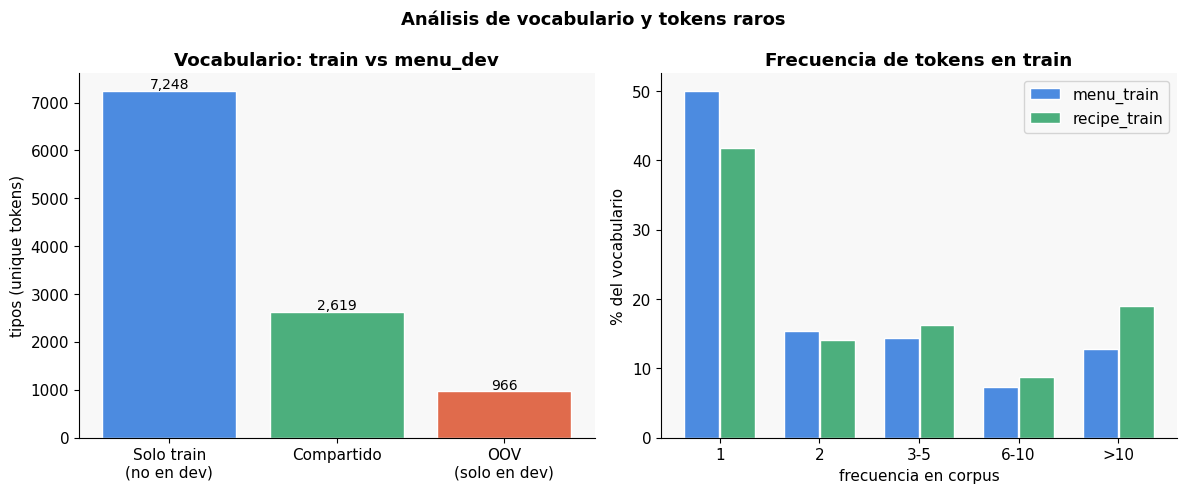


⚠️  Hapax en menu_train   : 4,222/8,432 = 50.1%
⚠️  Hapax en recipe_train : 1,015/2,424 = 41.9%
   → Alta tasa de hapax → riesgo de memorización en CRF


In [ ]:
mt_vocab = set(t.lower() for r in mt for t in r['tokens'])
rt_vocab = set(t.lower() for r in rt for t in r['tokens'])
md_vocab = set(t.lower() for r in md for t in r['tokens'])
rd_vocab = set(t.lower() for r in rd for t in r['tokens'])

all_train_vocab = mt_vocab | rt_vocab

oov_md = md_vocab - all_train_vocab
oov_rd = rd_vocab - all_train_vocab
shared_md = md_vocab & all_train_vocab

# OOV en instancias de tokens
oov_md_instances = sum(1 for r in md for t in r['tokens'] if t.lower() in oov_md)
total_md_tokens  = sum(len(r['tokens']) for r in md)

print('=== OOV Analysis ===')
print(f'  menu_train vocab   : {len(mt_vocab):,}')
print(f'  recipe_train vocab : {len(rt_vocab):,}')
print(f'  All train vocab    : {len(all_train_vocab):,}')
print(f'  menu_dev vocab     : {len(md_vocab):,}')
print(f'  OOV types          : {len(oov_md):,}  ({len(oov_md)/len(md_vocab)*100:.1f}% del vocab de dev)')
print(f'  OOV token instances: {oov_md_instances:,} / {total_md_tokens:,}  ({oov_md_instances/total_md_tokens*100:.1f}% de los tokens de dev)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
cats = ['Solo train\n(no en dev)', 'Compartido', 'OOV\n(solo en dev)']
vals = [len(all_train_vocab - md_vocab), len(shared_md), len(oov_md)]
colors = ['#4C8BE0', '#4CAF7D', '#E06B4C']
bars = ax.bar(cats, vals, color=colors, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, f'{v:,}', ha='center', fontsize=10)
ax.set_title('Vocabulario: train vs menu_dev', fontweight='bold')
ax.set_ylabel('tipos (unique tokens)')


ax2 = axes[1]
mt_freq = Counter(t.lower() for r in mt for t in r['tokens'])
rt_freq = Counter(t.lower() for r in rt for t in r['tokens'])

for name, freq, color in [('menu_train', mt_freq, '#4C8BE0'), ('recipe_train', rt_freq, '#4CAF7D')]:
    buckets = Counter()
    for c in freq.values():
        if c == 1: buckets['1'] += 1
        elif c == 2: buckets['2'] += 1
        elif c <= 5: buckets['3-5'] += 1
        elif c <= 10: buckets['6-10'] += 1
        else: buckets['>10'] += 1
    total = sum(buckets.values())
    keys = ['1','2','3-5','6-10','>10']
    pcts = [buckets[k]/total*100 for k in keys]
    x = np.arange(len(keys))
    width = 0.35
    offset = -0.18 if name == 'menu_train' else 0.18
    ax2.bar(x + offset, pcts, width, label=name, color=color, edgecolor='white')

ax2.set_xticks(np.arange(len(keys)))
ax2.set_xticklabels(keys)
ax2.set_title('Frecuencia de tokens en train', fontweight='bold')
ax2.set_xlabel('frecuencia en corpus')
ax2.set_ylabel('% del vocabulario')
ax2.legend()

plt.suptitle('Análisis de vocabulario y tokens raros', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

hapax_mt = sum(1 for c in mt_freq.values() if c == 1)
hapax_rt = sum(1 for c in rt_freq.values() if c == 1)
print(f'\n⚠️  Hapax en menu_train   : {hapax_mt:,}/{len(mt_freq):,} = {hapax_mt/len(mt_freq)*100:.1f}%')
print(f'⚠️  Hapax en recipe_train : {hapax_rt:,}/{len(rt_freq):,} = {hapax_rt/len(rt_freq)*100:.1f}%')
print('   → Alta tasa de hapax → riesgo de memorización en CRF')

## 5. Ambigüedad de tokens (misma palabra → distintas etiquetas)

Tokens con >1 etiqueta en menu_train: 3,388 / 8,432  (40.2%)


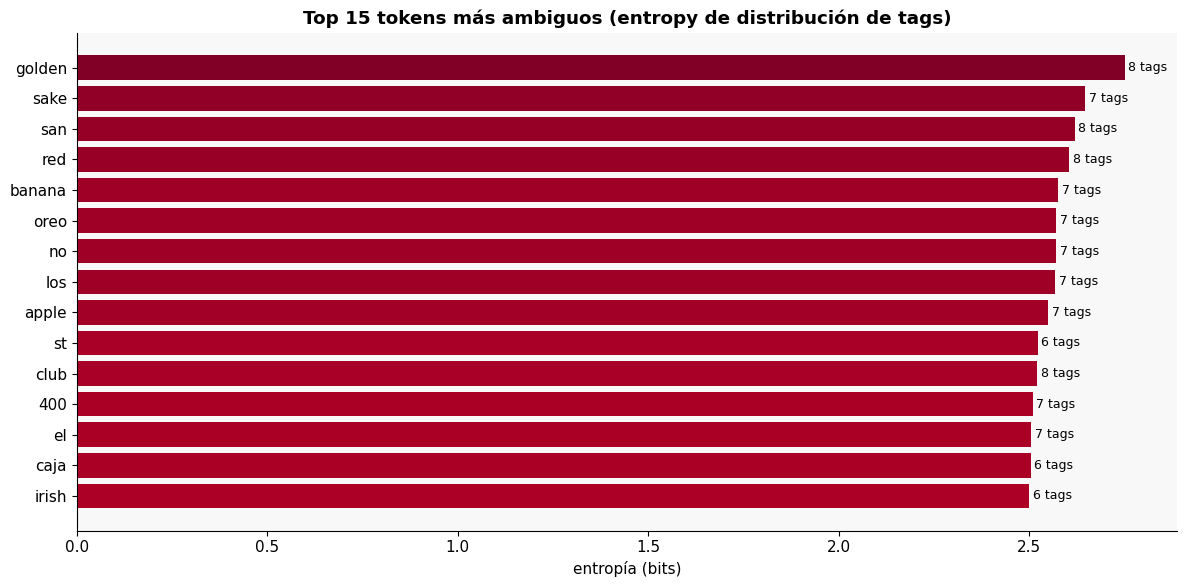


Detalle de los 10 tokens más ambiguos:
  golden           {'B-BEVERAGE': '25%', 'B-INGREDIENT': '25%', 'I-BEVERAGE': '12%', 'I-INGREDIENT': '12%', 'B-DISH': '6%', 'I-DISH': '6%', 'I-BRAND': '6%', 'B-BRAND': '6%'}
  sake             {'I-BEVERAGE': '21%', 'B-DISH': '21%', 'I-INGREDIENT': '21%', 'B-BEVERAGE': '14%', 'I-BRAND': '7%', 'I-DISH': '7%', 'B-INGREDIENT': '7%'}
  san              {'B-BEVERAGE': '26%', 'I-BEVERAGE': '22%', 'B-BRAND': '20%', 'I-INGREDIENT': '12%', 'I-DISH': '10%', 'I-BRAND': '6%', 'B-DISH': '2%', 'B-INGREDIENT': '2%'}
  red              {'I-BEVERAGE': '27%', 'B-BEVERAGE': '25%', 'B-BRAND': '20%', 'B-INGREDIENT': '11%', 'I-INGREDIENT': '6%', 'I-BRAND': '5%', 'B-DISH': '4%', 'I-DISH': '3%'}
  banana           {'B-INGREDIENT': '32%', 'I-DISH': '16%', 'I-BEVERAGE': '16%', 'B-DISH': '16%', 'B-BEVERAGE': '11%', 'I-INGREDIENT': '5%', 'I-BRAND': '5%'}
  oreo             {'I-INGREDIENT': '23%', 'B-BRAND': '23%', 'B-INGREDIENT': '19%', 'I-DISH': '15%', 'B-BEVERAGE': '12%', 

In [ ]:
token_tags_mt = defaultdict(Counter)
for r in mt:
    for tok, tag in zip(r['tokens'], r.get('ner_tags', [])):
        token_tags_mt[tok.lower()][tag] += 1

ambiguous = {tok: counts for tok, counts in token_tags_mt.items() if len(counts) > 1}
print(f'Tokens con >1 etiqueta en menu_train: {len(ambiguous):,} / {len(token_tags_mt):,}  ({len(ambiguous)/len(token_tags_mt)*100:.1f}%)')


def entropy(counts):
    total = sum(counts.values())
    return -sum((c/total) * np.log2(c/total) for c in counts.values() if c > 0)

top_amb = sorted(ambiguous.items(), key=lambda x: entropy(x[1]), reverse=True)[:15]

fig, ax = plt.subplots(figsize=(12, 6))

tokens_amb = [t for t, _ in top_amb]
entropies  = [entropy(c) for _, c in top_amb]
n_tags_per = [len(c) for _, c in top_amb]

colors_amb = plt.cm.YlOrRd(np.array(entropies) / max(entropies))
bars = ax.barh(tokens_amb, entropies, color=colors_amb)
for bar, nt in zip(bars, n_tags_per):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{nt} tags', va='center', fontsize=9)

ax.set_title('Top 15 tokens más ambiguos (entropy de distribución de tags)', fontweight='bold')
ax.set_xlabel('entropía (bits)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print('\nDetalle de los 10 tokens más ambiguos:')
for tok, counts in top_amb[:10]:
    total = sum(counts.values())
    dist = {k: f'{v/total*100:.0f}%' for k, v in counts.most_common()}
    print(f'  {tok:<15}  {dist}')

## 6. Longitud de spans de entidades

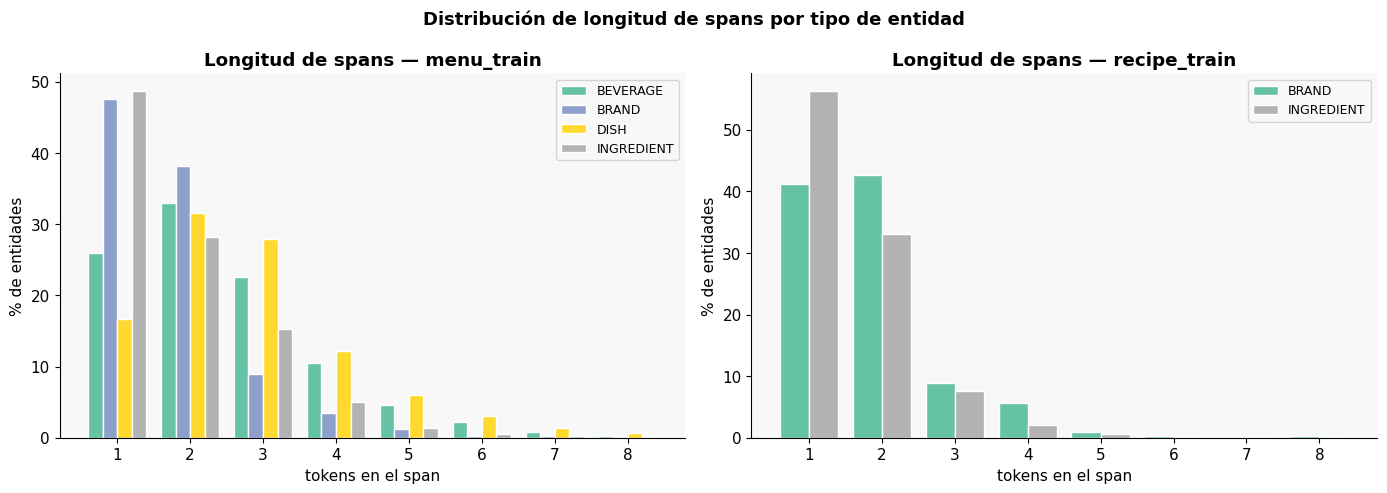

Estadísticas de spans:

  menu_train:
    BEVERAGE             n=6,664  avg=2.5  1-tok=26%  2-tok=33%
    BRAND                n=2,531  avg=1.8  1-tok=48%  2-tok=38%
    DISH                 n=5,430  avg=2.8  1-tok=17%  2-tok=32%
    INGREDIENT           n=19,246  avg=1.9  1-tok=49%  2-tok=28%

  recipe_train:
    BRAND                n=335  avg=1.8  1-tok=41%  2-tok=43%
    INGREDIENT           n=25,894  avg=1.6  1-tok=56%  2-tok=33%


In [7]:
def get_spans(records):
    spans = defaultdict(list)
    for r in records:
        tags = r.get('ner_tags', [])
        current, length = None, 0
        for tag in tags:
            if tag.startswith('B-'):
                if current: spans[current].append(length)
                current = tag[2:]; length = 1
            elif tag.startswith('I-'):
                length += 1
            else:
                if current: spans[current].append(length)
                current = None; length = 0
        if current: spans[current].append(length)
    return spans

mt_spans = get_spans(mt)
rt_spans = get_spans(rt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, spans) in zip(axes, [('menu_train', mt_spans), ('recipe_train', rt_spans)]):
    colors = plt.cm.Set2(np.linspace(0, 1, len(spans)))
    all_lens = sorted(set(l for ls in spans.values() for l in ls))
    max_show = min(8, max(all_lens))
    x = np.arange(1, max_show + 1)
    width = 0.8 / len(spans)

    for i, (etype, lengths) in enumerate(sorted(spans.items())):
        lc = Counter(lengths)
        total = len(lengths)
        pcts = [lc.get(j, 0) / total * 100 for j in range(1, max_show + 1)]
        offset = (i - len(spans)/2 + 0.5) * width
        ax.bar(x + offset, pcts, width, label=etype, color=colors[i], edgecolor='white')

    ax.set_title(f'Longitud de spans — {name}', fontweight='bold')
    ax.set_xlabel('tokens en el span')
    ax.set_ylabel('% de entidades')
    ax.set_xticks(x)
    ax.legend(fontsize=9)

plt.suptitle('Distribución de longitud de spans por tipo de entidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('Estadísticas de spans:')
for name, spans in [('menu_train', mt_spans), ('recipe_train', rt_spans)]:
    print(f'\n  {name}:')
    for etype, lengths in sorted(spans.items()):
        lc = Counter(lengths)
        print(f'    {etype:<20} n={len(lengths):,}  avg={statistics.mean(lengths):.1f}  '
              f'1-tok={lc[1]/len(lengths)*100:.0f}%  2-tok={lc[2]/len(lengths)*100:.0f}%')

## 7. Metadata: idiomas y cocinas

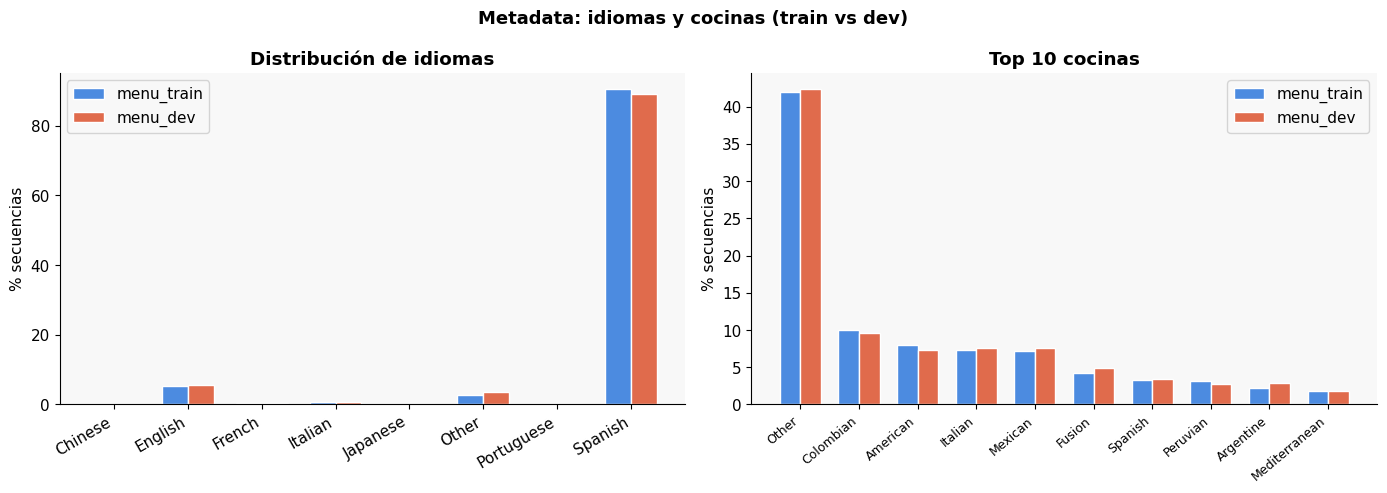

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Idiomas
ax = axes[0]
langs_mt = Counter(safe_str(r.get('meta_language', '?')) for r in mt)
langs_md = Counter(safe_str(r.get('meta_language', '?')) for r in md)
all_langs = sorted(set(list(langs_mt.keys()) + list(langs_md.keys())))
x = np.arange(len(all_langs))
w = 0.35
total_mt = len(mt); total_md = len(md)
ax.bar(x - w/2, [langs_mt.get(l, 0)/total_mt*100 for l in all_langs], w, label='menu_train', color='#4C8BE0', edgecolor='white')
ax.bar(x + w/2, [langs_md.get(l, 0)/total_md*100 for l in all_langs], w, label='menu_dev', color='#E06B4C', edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(all_langs, rotation=30, ha='right')
ax.set_title('Distribución de idiomas', fontweight='bold')
ax.set_ylabel('% secuencias')
ax.legend()

# Cocinas
ax2 = axes[1]
cuis_mt = Counter(safe_str(r.get('meta_origin_cuisine', '?')) for r in mt)
top_c = [c for c, _ in (cuis_mt + Counter(safe_str(r.get('meta_origin_cuisine', '?')) for r in md)).most_common(10)]
cuis_md = Counter(safe_str(r.get('meta_origin_cuisine', '?')) for r in md)
x2 = np.arange(len(top_c))
ax2.bar(x2 - w/2, [cuis_mt.get(c, 0)/total_mt*100 for c in top_c], w, label='menu_train', color='#4C8BE0', edgecolor='white')
ax2.bar(x2 + w/2, [cuis_md.get(c, 0)/total_md*100 for c in top_c], w, label='menu_dev', color='#E06B4C', edgecolor='white')
ax2.set_xticks(x2)
ax2.set_xticklabels(top_c, rotation=40, ha='right', fontsize=9)
ax2.set_title('Top 10 cocinas', fontweight='bold')
ax2.set_ylabel('% secuencias')
ax2.legend()

plt.suptitle('Metadata: idiomas y cocinas (train vs dev)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Diagnóstico de overfitting del CRF

╔══════════════════════════════════════════════════════╗
║      DIAGNÓSTICO DE OVERFITTING — CRF                ║
╠══════════════════════════════════════════════════════╣
║  Hapax en menu_train      : 4,222/8,432 = 50.1%     ║
║  Tokens raros (≤2) menu   : 65.5%                         ║
║  Hapax en recipe_train    : 41.9%                         ║
║  OOV types en menu_dev    : 26.9%                         ║
║  OOV instancias en dev    : 7.1%                         ║
║  Tokens ambiguos menu_tr  : 40.2%                         ║
║  recipe_train sin tag O   : 100% seqs                      ║
╠══════════════════════════════════════════════════════╣
║  RIESGOS IDENTIFICADOS:                              ║
║  [ALTO]   50%+ vocab de train son hapax              ║
║  [ALTO]   recipe_train sin clase O → falsos +        ║
║  [MEDIO]  40% tokens con tags ambiguas               ║
║  [MEDIO]  Domain shift: EN (recipe) → ES (menu)      ║
╚══════════════════════════════════════════════════════╝


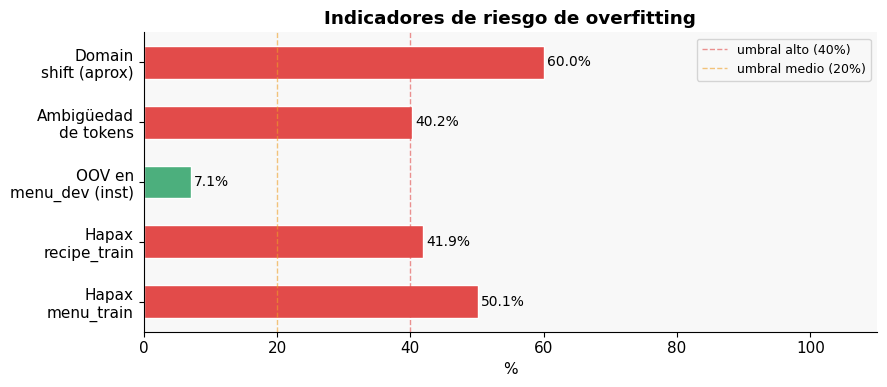

In [9]:
# Tokens en train que SOLO aparecen una vez (hapax)
mt_freq = Counter(t.lower() for r in mt for t in r['tokens'])
rt_freq = Counter(t.lower() for r in rt for t in r['tokens'])

hapax_mt   = sum(1 for c in mt_freq.values() if c == 1)
rare_mt    = sum(1 for c in mt_freq.values() if c <= 2)
hapax_rt   = sum(1 for c in rt_freq.values() if c == 1)
oov_pct_md = len(oov_md) / len(md_vocab) * 100
oov_inst   = oov_md_instances / total_md_tokens * 100
ambig_pct  = len(ambiguous) / len(token_tags_mt) * 100
rt_no_O    = 100.0  # 100% seqs en recipe_train sin tag O

print('╔══════════════════════════════════════════════════════╗')
print('║      DIAGNÓSTICO DE OVERFITTING — CRF                ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Hapax en menu_train      : {hapax_mt:,}/{len(mt_freq):,} = {hapax_mt/len(mt_freq)*100:.1f}%{" "*5}║')
print(f'║  Tokens raros (≤2) menu   : {rare_mt/len(mt_freq)*100:.1f}%{" "*25}║')
print(f'║  Hapax en recipe_train    : {hapax_rt/len(rt_freq)*100:.1f}%{" "*25}║')
print(f'║  OOV types en menu_dev    : {oov_pct_md:.1f}%{" "*25}║')
print(f'║  OOV instancias en dev    : {oov_inst:.1f}%{" "*25}║')
print(f'║  Tokens ambiguos menu_tr  : {ambig_pct:.1f}%{" "*25}║')
print(f'║  recipe_train sin tag O   : {rt_no_O:.0f}% seqs{" "*22}║')
print('╠══════════════════════════════════════════════════════╣')
print('║  RIESGOS IDENTIFICADOS:                              ║')
print('║  [ALTO]   50%+ vocab de train son hapax              ║')
print('║  [ALTO]   recipe_train sin clase O → falsos +        ║')
print('║  [MEDIO]  40% tokens con tags ambiguas               ║')
print('║  [MEDIO]  Domain shift: EN (recipe) → ES (menu)      ║')
print('╚══════════════════════════════════════════════════════╝')

# Visualización radar
from matplotlib.patches import FancyArrowPatch

risks = {
    'Hapax\nmenu_train': hapax_mt / len(mt_freq) * 100,
    'Hapax\nrecipe_train': hapax_rt / len(rt_freq) * 100,
    'OOV en\nmenu_dev (inst)': oov_inst,
    'Ambigüedad\nde tokens': ambig_pct,
    'Domain\nshift (aprox)': 60,  # estimado: vocabs casi disjuntos entre recipe(EN) y menu(ES)
}

fig, ax = plt.subplots(figsize=(9, 4))
colors_r = ['#E24B4A' if v > 40 else '#EF9F27' if v > 20 else '#4CAF7D' for v in risks.values()]
bars_r = ax.barh(list(risks.keys()), list(risks.values()), color=colors_r, edgecolor='white', height=0.55)
ax.axvline(40, color='#E24B4A', linestyle='--', linewidth=1, alpha=0.6, label='umbral alto (40%)')
ax.axvline(20, color='#EF9F27', linestyle='--', linewidth=1, alpha=0.6, label='umbral medio (20%)')
for bar, v in zip(bars_r, risks.values()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{v:.1f}%', va='center', fontsize=10)
ax.set_xlabel('%')
ax.set_title('Indicadores de riesgo de overfitting', fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(0, 110)
plt.tight_layout()
plt.show()

## 9. Recomendaciones para superar F1=0.74

In [10]:
recomendaciones = [
    {
        'titulo': '1. Agregar clase O al entrenamiento combinado',
        'impacto': 'ALTO',
        'detalle': (
            'recipe_train NO tiene tokens con tag O. El CRF aprende a etiquetar '
            'SIEMPRE como entidad. Solución: filtrar recipe_train solo como '
            'features auxiliares o agregar secuencias sintéticas con O.'
        )
    },
    {
        'titulo': '2. Aumentar regularización del CRF',
        'impacto': 'ALTO',
        'detalle': (
            'Con 50%+ hapax, el CRF memoriza tokens raros. '
            'Aumentar c1 (L1) de 0.1 a 0.3-0.5 y c2 (L2) de 0.1 a 0.2. '
            'También prueba max_iterations=200 con early stopping.'
        )
    },
    {
        'titulo': '3. Features morfológicas más ricas (OOV mitigation)',
        'impacto': 'ALTO',
        'detalle': (
            '7.1% de tokens en dev son OOV. Agregar: suffix_4, suffix_5, '
            'shape ("Xxx", "xx", "d"), char n-grams (2-4). '
            'Estas features generalizan sin necesitar token exacto.'
        )
    },
    {
        'titulo': '4. Usar meta_language y meta_origin_cuisine como features',
        'impacto': 'MEDIO',
        'detalle': (
            '89% del dataset de menú está en español. El dominio ya existe '
            'en menu_train. Pasar idioma y cocina como feature global de secuencia '
            'permite al CRF ajustar sus pesos por contexto cultural.'
        )
    },
    {
        'titulo': '5. Separar entrenamiento por dominio (no mezclar igual)',
        'impacto': 'MEDIO',
        'detalle': (
            'recipe_train (inglés, sin O) y menu_train (español, con O) son '
            'muy distintos. Considera entrenar con menu_train como fuente primaria '
            'y recipe_train solo para features de INGREDIENT/BRAND via tag dictionary.'
        )
    },
    {
        'titulo': '6. Considerar transformer fine-tuning (mBERT / XLM-R)',
        'impacto': 'MUY ALTO',
        'detalle': (
            'Para superar ~0.80 F1, el CRF tiene un techo práctico. '
            'XLM-RoBERTa-base con fine-tuning sobre menu_train debería '
            'dar F1 0.82-0.88 en este tipo de tarea multilingüe.'
        )
    },
]

impacto_color = {'ALTO': '#E06B4C', 'MEDIO': '#EF9F27', 'MUY ALTO': '#A32D2D'}

for rec in recomendaciones:
    color = impacto_color.get(rec['impacto'], 'gray')
    print(f"\033[1m{rec['titulo']}\033[0m")
    print(f"  Impacto estimado: {rec['impacto']}")
    print(f"  {rec['detalle']}")
    print()

1. Agregar clase O al entrenamiento combinado
  Impacto estimado: ALTO
  recipe_train NO tiene tokens con tag O. El CRF aprende a etiquetar SIEMPRE como entidad. Solución: filtrar recipe_train solo como features auxiliares o agregar secuencias sintéticas con O.

2. Aumentar regularización del CRF
  Impacto estimado: ALTO
  Con 50%+ hapax, el CRF memoriza tokens raros. Aumentar c1 (L1) de 0.1 a 0.3-0.5 y c2 (L2) de 0.1 a 0.2. También prueba max_iterations=200 con early stopping.

3. Features morfológicas más ricas (OOV mitigation)
  Impacto estimado: ALTO
  7.1% de tokens en dev son OOV. Agregar: suffix_4, suffix_5, shape ("Xxx", "xx", "d"), char n-grams (2-4). Estas features generalizan sin necesitar token exacto.

4. Usar meta_language y meta_origin_cuisine como features
  Impacto estimado: MEDIO
  89% del dataset de menú está en español. El dominio ya existe en menu_train. Pasar idioma y cocina como feature global de secuencia permite al CRF ajustar sus pesos por contexto cultural.



# CONTINUACION DE EDA